<a href="https://colab.research.google.com/github/Khulbe-Nitin/Volt-Relay/blob/main/Collab_notebook/Nitin_4_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# VoltRelay Energy - Data Analytics Hackathon
# Author: Khulbe
# Dataset: Synthetic Battery-Swapping Network

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Volt_relay/raw/"

In [ ]:
stations = pd.read_csv(DATA_PATH + "stations.csv")
riders = pd.read_csv(DATA_PATH + "riders.csv")
fleet_partners = pd.read_csv(DATA_PATH + "fleet_partners.csv")
support_tickets = pd.read_csv(DATA_PATH + "support_tickets.csv")

<h2>Stations - Understanding DataSet</h2>

In [ ]:
print(stations.shape)

(152, 22)


In [ ]:
stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   station_id                     152 non-null    object 
 1   city                           152 non-null    object 
 2   zone                           152 non-null    object 
 3   latitude                       152 non-null    float64
 4   longitude                      152 non-null    float64
 5   location_type                  152 non-null    object 
 6   host_type                      152 non-null    object 
 7   commissioned_date              152 non-null    object 
 8   decommissioned_date            1 non-null      object 
 9   expansion_wave                 152 non-null    object 
 10  charger_generation             152 non-null    object 
 11  slots_2w                       152 non-null    int64  
 12  slots_3w                       152 non-null    int

In [ ]:
display(stations.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
station_id,152,152,STN-BLR-001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,152,6,Bengaluru,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zone,152,28,PUN-South,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,152.0,NaN,NaN,NaN,20.130857,5.73694,12.799911,17.234749,18.591899,26.850718,28.747185
longitude,152.0,NaN,NaN,NaN,76.214074,1.994029,72.886092,73.770932,77.101079,77.605381,78.59181
location_type,152,6,market,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_type,152,4,mall_parking,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
commissioned_date,152,117,2023-11-07,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
decommissioned_date,1,1,2025-05-20,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
expansion_wave,152,3,Launch,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
display(stations.isna().sum().sort_values(ascending=False))

,0
decommissioned_date,151
competitor_within_1_5km_since,142
zone,0
latitude,0
station_id,0
city,0
location_type,0
longitude,0
commissioned_date,0
host_type,0


In [ ]:
print("Duplicate rows:", stations.duplicated().sum())
print("Duplicate station IDs:", stations["station_id"].duplicated().sum())

Duplicate rows: 0
Duplicate station IDs: 0


In [ ]:
categorical_columns = [
    "city",
    "zone",
    "location_type",
    "host_type",
    "expansion_wave",
    "charger_generation",
    "connectivity_tier",
    "firmware_version"
]

for col in categorical_columns:
    print("\n" + "=" * 50)
    print(col)
    print("=" * 50)
    print(stations[col].value_counts(dropna=False))


city
city
Bengaluru    34
Delhi NCR    30
Hyderabad    26
Pune         22
Mumbai       22
Jaipur       18
Name: count, dtype: int64

zone
zone
PUN-South              12
BLR-Central            10
HYD-Central            10
JAI-Malviya Nagar      10
MUM-Andheri             9
BLR-East                8
DEL-West                8
MUM-Central             8
DEL-East                7
PUN-Central             7
JAI-Vaishali            7
BLR-Electronic City     7
DEL-Noida               6
HYD-Secunderabad        6
HYD-Hitech City         5
DEL-Gurugram-Cyber      5
BLR-Whitefield          4
MUM-Navi Mumbai         3
DEL-South               3
BLR-North               3
HYD-West                3
BLR-South               2
PUN-Hinjewadi           2
HYD-South               2
MUM-Thane               2
DEL-Central             1
PUN-Kharadi             1
JAI-Central             1
Name: count, dtype: int64

location_type
location_type
market               47
commercial_hub       46
highway_fuel_pump    21
r

In [ ]:
numeric_columns = [
    "latitude",
    "longitude",
    "slots_2w",
    "slots_3w",
    "inventory_target_2w",
    "inventory_target_3w",
    "monthly_rent_inr",
    "monthly_maintenance_inr",
    "grid_tariff_inr_kwh"
]

display(stations[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
latitude,152.0,20.130857,5.736940,12.799911,17.234749,18.591899,26.850718,28.747185
longitude,152.0,76.214074,1.994029,72.886092,73.770932,77.101079,77.605381,78.591810
slots_2w,152.0,12.289474,3.225789,8.000000,8.000000,12.000000,16.000000,16.000000
slots_3w,152.0,2.223684,2.599535,0.000000,0.000000,0.000000,4.000000,6.000000
inventory_target_2w,152.0,22.578947,9.701182,6.000000,15.000000,21.000000,29.000000,46.000000
inventory_target_3w,152.0,2.657895,3.105443,0.000000,0.000000,0.000000,5.000000,8.000000
monthly_rent_inr,152.0,17707.480263,6354.331398,9054.000000,12169.500000,16901.500000,22012.250000,35719.000000
monthly_maintenance_inr,152.0,5932.822368,879.811239,4503.000000,5075.500000,5890.000000,6687.750000,7497.000000
grid_tariff_inr_kwh,152.0,9.301579,0.772910,7.500000,8.785000,9.215000,9.787500,11.700000


In [ ]:
#for Displaying nonsensical values
for col in numeric_columns:
    print(f"\n{col}")
    print("Min:", stations[col].min())
    print("Max:", stations[col].max())


latitude
Min: 12.799911
Max: 28.747185

longitude
Min: 72.886092
Max: 78.59181

slots_2w
Min: 8
Max: 16

slots_3w
Min: 0
Max: 6

inventory_target_2w
Min: 6
Max: 46

inventory_target_3w
Min: 0
Max: 8

monthly_rent_inr
Min: 9054
Max: 35719

monthly_maintenance_inr
Min: 4503
Max: 7497

grid_tariff_inr_kwh
Min: 7.5
Max: 11.7


In [ ]:
date_columns = [
    "commissioned_date",
    "decommissioned_date",
    "firmware_updated_date",
    "competitor_within_1_5km_since"
]

for col in date_columns:
    stations[col] = pd.to_datetime(
        stations[col],
        errors="coerce"
    )

In [ ]:
display(stations[date_columns].describe().T)

,count,mean,min,25%,50%,75%,max
commissioned_date,152,2024-03-12 12:37:53.684210432,2023-06-01 00:00:00,2023-08-26 00:00:00,2023-11-14 12:00:00,2024-10-08 12:00:00,2025-04-28 00:00:00
decommissioned_date,1,2025-05-20 00:00:00,2025-05-20 00:00:00,2025-05-20 00:00:00,2025-05-20 00:00:00,2025-05-20 00:00:00,2025-05-20 00:00:00
firmware_updated_date,152,2025-03-30 22:53:41.052631552,2025-03-10 00:00:00,2025-03-10 00:00:00,2025-04-14 00:00:00,2025-04-14 00:00:00,2025-04-14 00:00:00
competitor_within_1_5km_since,10,2025-01-15 00:00:00,2025-01-15 00:00:00,2025-01-15 00:00:00,2025-01-15 00:00:00,2025-01-15 00:00:00,2025-01-15 00:00:00


In [ ]:
# Since decommissioning cannot happen before commissioning
invalid_dates = stations[
    stations["decommissioned_date"].notna() &
    (stations["decommissioned_date"] < stations["commissioned_date"])
]

display(invalid_dates)

,station_id,city,zone,latitude,longitude,location_type,host_type,commissioned_date,decommissioned_date,expansion_wave,...,slots_3w,inventory_target_2w,inventory_target_3w,monthly_rent_inr,monthly_maintenance_inr,grid_tariff_inr_kwh,connectivity_tier,firmware_version,firmware_updated_date,competitor_within_1_5km_since


In [ ]:
missing = stations.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
display(missing)

,0
decommissioned_date,151
competitor_within_1_5km_since,142


In [ ]:
#replacing the missing values from the columns
stations["is_active"] = stations["decommissioned_date"].isna()
stations["has_nearby_competitor"] = (
    stations["competitor_within_1_5km_since"].notna()
)

In [ ]:
#Now I am creating some features to the dataset
stations["total_slots"] = (
    stations["slots_2w"] +
    stations["slots_3w"]
) #total_slots
stations["total_inventory_target"] = (
    stations["inventory_target_2w"] +
    stations["inventory_target_3w"]
) #total_inventory

#Fixed monthly station cost
stations["monthly_fixed_cost_inr"] = (
    stations["monthly_rent_inr"] +
    stations["monthly_maintenance_inr"]
)

In [ ]:
#Station age in days and months
analysis_date = pd.Timestamp("2026-09-26")

stations["station_age_days"] = (
    analysis_date - stations["commissioned_date"]
).dt.days

stations["station_age_months"] = (
    stations["station_age_days"] / 30
).round(1)

<h1> EDA- Station </h1>

In [ ]:
city_counts = stations["city"].value_counts()

display(city_counts)

,count
city,
Bengaluru,34
Delhi NCR,30
Hyderabad,26
Pune,22
Mumbai,22
Jaipur,18


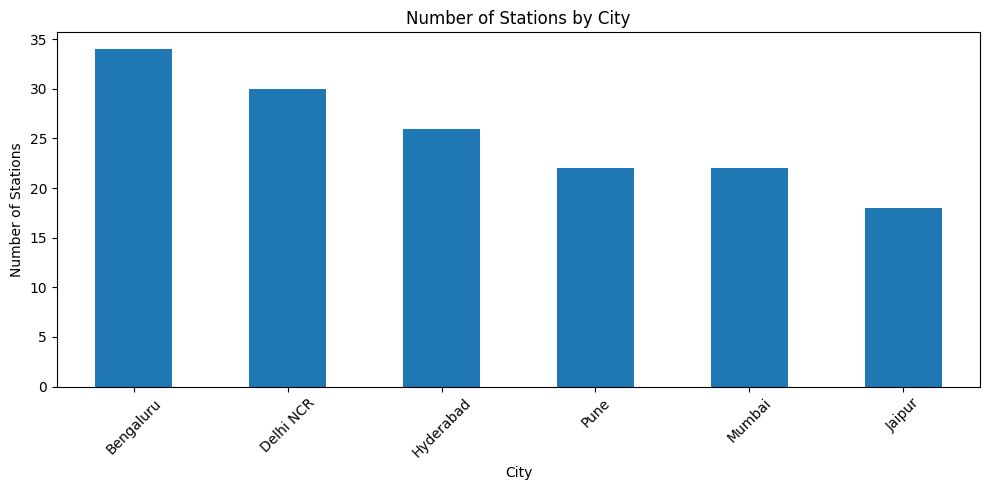

In [ ]:
plt.figure(figsize=(10, 5))

city_counts.plot(kind="bar")

plt.title("Number of Stations by City")
plt.xlabel("City")
plt.ylabel("Number of Stations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#plot depicting Stations density by city

In [ ]:
#charger generation
display(
    pd.crosstab(
        stations["city"],
        stations["charger_generation"]
    )
)
#Location
display(
    stations["location_type"].value_counts()
)

charger_generation,Gen1,Gen2,Gen3
city,,,
Bengaluru,9,18,7
Delhi NCR,13,10,7
Hyderabad,13,6,7
Jaipur,10,3,5
Mumbai,2,15,5
Pune,4,12,6


,count
location_type,
market,47
commercial_hub,46
highway_fuel_pump,21
residential,21
transit_hub,10
tech_park,7


In [ ]:
#Station's economic feature
display(
    stations[
        [
            "city",
            "monthly_rent_inr",
            "monthly_maintenance_inr",
            "monthly_fixed_cost_inr",
            "grid_tariff_inr_kwh"
        ]
    ].groupby("city").mean().round(2)
)

,monthly_rent_inr,monthly_maintenance_inr,monthly_fixed_cost_inr,grid_tariff_inr_kwh
city,,,,
Bengaluru,15720.09,6130.85,21850.94,9.28
Delhi NCR,16155.57,6029.07,22184.63,9.18
Hyderabad,17191.77,5677.12,22868.88,9.07
Jaipur,17022.72,5895.78,22918.50,9.06
Mumbai,25843.41,5667.73,31511.14,10.16
Pune,15928.95,6093.14,22022.09,9.12


In [ ]:
stations.columns.tolist()

['station_id',
 'city',
 'zone',
 'latitude',
 'longitude',
 'location_type',
 'host_type',
 'commissioned_date',
 'decommissioned_date',
 'expansion_wave',
 'charger_generation',
 'slots_2w',
 'slots_3w',
 'inventory_target_2w',
 'inventory_target_3w',
 'monthly_rent_inr',
 'monthly_maintenance_inr',
 'grid_tariff_inr_kwh',
 'connectivity_tier',
 'firmware_version',
 'firmware_updated_date',
 'competitor_within_1_5km_since',
 'is_active',
 'has_nearby_competitor',
 'total_slots',
 'total_inventory_target',
 'monthly_fixed_cost_inr',
 'station_age_days',
 'station_age_months']

<h1> <b> #2 Dataset </b></h1> <h1> **Riders** </h1>

In [ ]:
print("Shape:", riders.shape)

display(riders.head())

riders.info()

Shape: (20000, 12)


,rider_id,partner_id,vehicle_class,vehicle_model,home_zone,signup_date,signup_channel,plan_type,declared_shift,age_band,kyc_verified,home_city
0,RD-1000000,FP-04,3W,Kranti Cargo3,DEL-Noida,2023-03-08,field_agent,partner_billed,night,45+,True,Delhi NCR
1,RD-1000001,FP-05,2W,Volt Cub,MUM-Thane,2023-03-08,partner_onboarding,partner_billed,mixed,35-44,True,Mumbai
2,RD-1000002,FP-06,2W,Torq X1,HYD-West,2023-03-08,partner_onboarding,partner_billed,evening,25-34,False,Hyderabad
3,RD-1000003,FP-01,2W,Zipp E2,MUM-Navi Mumbai,2023-03-08,partner_onboarding,partner_billed,evening,25-34,True,Mumbai
4,RD-1000004,FP-02,2W,Zipp E2,HYD-Hitech City,2023-03-08,partner_onboarding,partner_billed,night,NaN,True,Hyderabad


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   rider_id        20000 non-null  object
 1   partner_id      12372 non-null  object
 2   vehicle_class   20000 non-null  object
 3   vehicle_model   20000 non-null  object
 4   home_zone       20000 non-null  object
 5   signup_date     20000 non-null  object
 6   signup_channel  20000 non-null  object
 7   plan_type       20000 non-null  object
 8   declared_shift  16338 non-null  object
 9   age_band        18453 non-null  object
 10  kyc_verified    20000 non-null  bool  
 11  home_city       20000 non-null  object
dtypes: bool(1), object(11)
memory usage: 1.7+ MB


In [ ]:
display(riders.isna().sum().sort_values(ascending=False))

,0
partner_id,7628
declared_shift,3662
age_band,1547
rider_id,0
vehicle_model,0
vehicle_class,0
home_zone,0
signup_date,0
plan_type,0
signup_channel,0


In [ ]:
print("Duplicate rows:", riders.duplicated().sum())
print("Duplicate rider IDs:", riders["rider_id"].duplicated().sum())
print("Unique riders:", riders["rider_id"].nunique())

Duplicate rows: 0
Duplicate rider IDs: 0
Unique riders: 20000


In [ ]:
display(riders.describe(include="all").T)

,count,unique,top,freq
rider_id,20000,20000,RD-1019983,1
partner_id,12372,12,FP-01,2710
vehicle_class,20000,2,2W,17107
vehicle_model,20000,8,Zipp E2,5674
home_zone,20000,28,JAI-Malviya Nagar,1528
signup_date,20000,817,2024-10-22,68
signup_channel,20000,4,partner_onboarding,9376
plan_type,20000,3,partner_billed,12372
declared_shift,16338,4,evening,5961
age_band,18453,4,25-34,6878


In [ ]:
#We notice that there are some riders without a partner id. These are individual riders, so we group them
#based on whehter they have a plan with a partner or not.
# ============================================
# RIDERS - PARTNER CONSISTENCY
# ============================================

print("Plan type distribution:")
display(riders["plan_type"].value_counts(dropna=False))

print("\nPartner ID missing by plan type:")
display(
    riders.groupby("plan_type")["partner_id"]
    .apply(lambda x: x.isna().sum())
)

Plan type distribution:


,count
plan_type,
partner_billed,12372
pay_as_you_go,5299
prepaid_pack,2329



Partner ID missing by plan type:


,partner_id
plan_type,
partner_billed,0
pay_as_you_go,5299
prepaid_pack,2329


In [ ]:
print("\nPlan type for riders WITH partner_id:")
display(
    riders.loc[riders["partner_id"].notna(), "plan_type"]
    .value_counts(dropna=False)
)

print("\nPlan type for riders WITHOUT partner_id:")
display(
    riders.loc[riders["partner_id"].isna(), "plan_type"]
    .value_counts(dropna=False)
)


Plan type for riders WITH partner_id:


,count
plan_type,
partner_billed,12372



Plan type for riders WITHOUT partner_id:


,count
plan_type,
pay_as_you_go,5299
prepaid_pack,2329


In [ ]:
riders["is_fleet_rider"] = riders["partner_id"].notna()

In [ ]:
display(
    riders["partner_id"]
    .value_counts(dropna=False)
)
print("Unique non-null partners:",
      riders["partner_id"].nunique())

,count
partner_id,
NaN,7628
FP-01,2710
FP-03,2381
FP-02,1766
FP-05,1254
FP-04,869
FP-06,608
FP-07,532
FP-10,519


Unique non-null partners: 12


In [ ]:
#Problem statement warns about home_city, so we are checking home_cities inconsistency
display(
    riders["home_city"]
    .value_counts()
)
print("Number of home cities", riders["home_city"].nunique())

,count
home_city,
Bengaluru,4175
Delhi NCR,3783
Hyderabad,3396
Pune,2843
Mumbai,2772
Jaipur,2446
Bombay,53
BLR,53
bengaluru,50


Number of home cities 21


In [ ]:
display(
    riders[
        ["home_city", "home_zone"]
    ]
    .drop_duplicates()
    .sort_values(["home_city", "home_zone"])
    .to_string(index=False)
)

' home_city           home_zone\n       BLR         BLR-Central\n       BLR            BLR-East\n       BLR BLR-Electronic City\n       BLR           BLR-North\n       BLR           BLR-South\n       BLR      BLR-Whitefield\n Bangalore         BLR-Central\n Bangalore            BLR-East\n Bangalore BLR-Electronic City\n Bangalore           BLR-North\n Bangalore           BLR-South\n Bangalore      BLR-Whitefield\n Bengaluru         BLR-Central\n Bengaluru            BLR-East\n Bengaluru BLR-Electronic City\n Bengaluru           BLR-North\n Bengaluru           BLR-South\n Bengaluru      BLR-Whitefield\n    Bombay         MUM-Andheri\n    Bombay         MUM-Central\n    Bombay     MUM-Navi Mumbai\n    Bombay           MUM-Thane\n     Delhi         DEL-Central\n     Delhi            DEL-East\n     Delhi  DEL-Gurugram-Cyber\n     Delhi           DEL-Noida\n     Delhi           DEL-South\n     Delhi            DEL-West\n Delhi NCR         DEL-Central\n Delhi NCR            DEL-East\n Delhi 

<h3> Checking vehicle info </h3>

In [ ]:
display(riders["vehicle_class"].value_counts())

print("\nVehicle models:")
display(riders["vehicle_model"].value_counts())

,count
vehicle_class,
2W,17107
3W,2893



Vehicle models:


,count
vehicle_model,
Zipp E2,5674
Kranti Spark,2370
Volt Cub,2283
Orbit Lite,2273
Torq X1,2271
Nova Ray,2236
Kranti Cargo3,1492
Torq Hauler,1401


In [ ]:
display(
    pd.crosstab(
        riders["vehicle_class"],
        riders["vehicle_model"]
    )
)

vehicle_model,Kranti Cargo3,Kranti Spark,Nova Ray,Orbit Lite,Torq Hauler,Torq X1,Volt Cub,Zipp E2
vehicle_class,,,,,,,,
2W,0,2370,2236,2273,0,2271,2283,5674
3W,1492,0,0,0,1401,0,0,0


<h2> DATA PROCESSING </h2>

In [ ]:
riders["signup_date"] = pd.to_datetime(
    riders["signup_date"],
    errors="coerce"
)

print("Missing signup dates:",
      riders["signup_date"].isna().sum())

print("Earliest signup:",
      riders["signup_date"].min())

print("Latest signup:",
      riders["signup_date"].max())

Missing signup dates: 0
Earliest signup: 2023-03-08 00:00:00
Latest signup: 2025-06-30 00:00:00


In [ ]:
display(
    riders["signup_date"].describe()
)

,signup_date
count,20000
mean,2024-08-12 09:43:16.320000
min,2023-03-08 00:00:00
25%,2024-03-12 00:00:00
50%,2024-09-30 00:00:00
75%,2025-02-17 00:00:00
max,2025-06-30 00:00:00


<h2> Feature Engineering </h2>

In [ ]:
#Signup Features
riders["signup_year"] = (
    riders["signup_date"].dt.year
)

riders["signup_month"] = (
    riders["signup_date"].dt.month
)

riders["signup_month_name"] = (
    riders["signup_date"].dt.strftime("%b")
)

riders["signup_year_month"] = (
    riders["signup_date"].dt.to_period("M")
    .astype(str)
)

In [ ]:
riders["signup_day_of_week"] = (
    riders["signup_date"].dt.day_name()
)

In [ ]:
#Fleet_rider Features
riders["is_fleet_rider"] = (
    riders["partner_id"].notna()
)

In [ ]:
display(
    riders["is_fleet_rider"].value_counts()
)

,count
is_fleet_rider,
True,12372
False,7628


In [ ]:
# Just displaying it out of 100
display(
    riders["is_fleet_rider"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
riders["partner_id"].isna().sum(

)

,proportion
is_fleet_rider,
True,61.86
False,38.14


np.int64(7628)

In [ ]:
#filling missing values in declared_shifts and Age_band
riders["declared_shift_clean"] = (
    riders["declared_shift"]
    .fillna("Not declared")
)

riders["age_band_clean"] = (
    riders["age_band"]
    .fillna("Not declared")
)

In [ ]:
display(
    riders["declared_shift_clean"].value_counts()
)

display(
    riders["age_band_clean"].value_counts()
)

,count
declared_shift_clean,
evening,5961
day,4366
Not declared,3662
mixed,3185
night,2826


,count
age_band_clean,
25-34,6878
18-24,5608
35-44,4024
45+,1943
Not declared,1547


In [ ]:
#KYC has NO Missing values and has only 2 unique values
display(
    riders["kyc_verified"].value_counts(dropna=False)
)

,count
kyc_verified,
True,19254
False,746


In [ ]:
print(
    "KYC verification rate:",
    round(riders["kyc_verified"].mean() * 100, 2),
    "%"
)

KYC verification rate: 96.27 %


<h1> Basic EDA </h1>

In [ ]:
#Riders by vehicle class 2W, 3W
vehicle_class_counts = (
    riders["vehicle_class"]
    .value_counts()
)

display(vehicle_class_counts)

,count
vehicle_class,
2W,17107
3W,2893


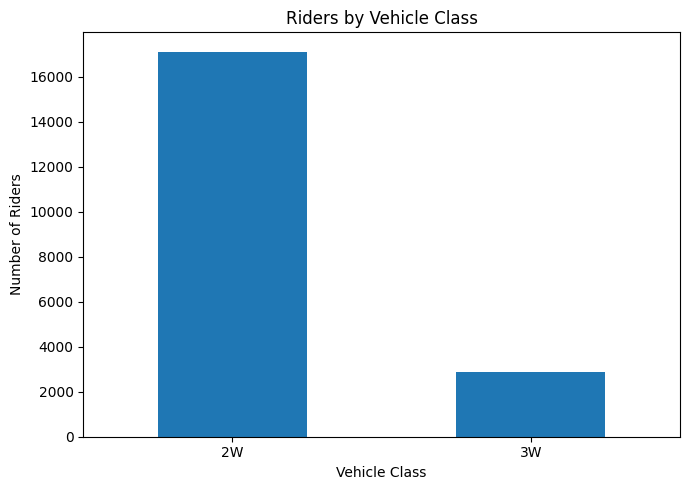

In [ ]:
#Plotting riders by class
plt.figure(figsize=(7, 5))

vehicle_class_counts.plot(kind="bar")

plt.title("Riders by Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("Number of Riders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
#rider by channel
display(
    riders["signup_channel"].value_counts()
)

,count
signup_channel,
partner_onboarding,9376
app_store,4215
field_agent,4144
referral,2265


In [ ]:
#riders by plan
display(
    riders["plan_type"].value_counts()
)

,count
plan_type,
partner_billed,12372
pay_as_you_go,5299
prepaid_pack,2329


In [ ]:
#Fleet vs Independent riders
display(
    riders["is_fleet_rider"].value_counts()
)

,count
is_fleet_rider,
True,12372
False,7628


In [ ]:
#Cross analysis b/w different features
fleet_by_vehicle = pd.crosstab(
    riders["vehicle_class"],
    riders["is_fleet_rider"]
)

display(fleet_by_vehicle)

is_fleet_rider,False,True
vehicle_class,,
2W,6956,10151
3W,672,2221


In [ ]:
plan_by_vehicle = pd.crosstab(
    riders["vehicle_class"],
    riders["plan_type"]
)

display(plan_by_vehicle)

plan_type,partner_billed,pay_as_you_go,prepaid_pack
vehicle_class,,,
2W,10151,4823,2133
3W,2221,476,196


In [ ]:
#Signup vs Plan_type
channel_by_plan = pd.crosstab(
    riders["signup_channel"],
    riders["plan_type"]
)

display(channel_by_plan)

plan_type,partner_billed,pay_as_you_go,prepaid_pack
signup_channel,,,
app_store,0,2924,1291
field_agent,2996,795,353
partner_onboarding,9376,0,0
referral,0,1580,685


In [ ]:
#Checking whether fleet-rider and independent rider differ by signup channels
display(
    pd.crosstab(
        riders["signup_channel"],
        riders["is_fleet_rider"],
        normalize="index"
    ).round(3) * 100
)

is_fleet_rider,False,True
signup_channel,,
app_store,100.0,0.0
field_agent,27.7,72.3
partner_onboarding,0.0,100.0
referral,100.0,0.0


<h1> <b> Saving Cleaned Riders and Stations file </h1> </b>

In [ ]:
CLEAN_PATH = "/content/drive/MyDrive/VoltRelay/cleaned/"

In [ ]:
riders.to_csv(
    CLEAN_PATH + "riders_clean.csv",
    index=False
)

print("Saved successfully.")